In [1]:
import sys, platform

print('Python',sys.version)
print(platform.system())
print('shell start: shift + enter')

Python 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:29:10) [GCC 14.3.0]
Linux
shell start: shift + enter


In [2]:
import torch
import numpy as np
import pandas as pd


print('Pytorch', torch.__version__)
print('CUDA:', torch.cuda.is_available())

Pytorch 2.8.0+cu128
CUDA: True


%pwd

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
print(type(iris))
print(iris.keys())

print(iris.target_names, '->', np.unique(iris.target))
print(iris.data.shape)
iris.frame = pd.DataFrame(iris.data, columns=iris.feature_names)
# iris.frame['target'] = iris.frame.target



<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
['setosa' 'versicolor' 'virginica'] -> [0 1 2]
(150, 4)


In [5]:
from sklearn.linear_model import LogisticRegression

max_learn_cnt = 1000
model = LogisticRegression(max_iter=max_learn_cnt)
model.fit(iris.data, iris.target)

predict_1=model.predict(iris.data)
check= predict_1 == iris.target
print(f'{check.sum()}/{len(check)} = {check.mean():.1%}')
false_cnt = np.logical_not(check)
iris.frame.assign(predict_1=predict_1)[false_cnt]
# iris.frame.assign(predict_1=predict_1).sample(5)



146/150 = 97.3%


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),predict_1
70,5.9,3.2,4.8,1.8,2
77,6.7,3.0,5.0,1.7,2
83,6.0,2.7,5.1,1.6,2
106,4.9,2.5,4.5,1.7,1


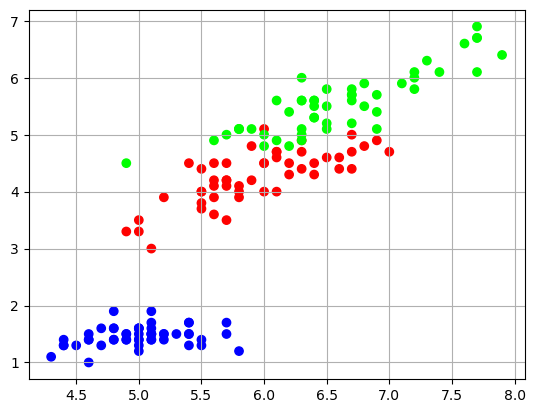

In [34]:
import matplotlib.pyplot as plt
plt.scatter(x=iris.data[:, 0], y=iris.data[:,2], c=iris.target, cmap='brg')
#plt.scatter(x=iris.data[false_cnt, 0], y=iris.data[false_cnt, 2], c ='k', marker='x')
plt.grid()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
#plt.scatter(x=iris.data[:, 0], y=iris.data[:,2], c=iris.target, cmap='brg')
plt.scatter(x=iris.data[false_cnt, 0], y=iris.data[false_cnt, 2], c ='k', marker='x')
plt.grid()
plt.show()


In [23]:

W = model.coef_
b = model.intercept_
print(f'W: {W.shape}, b: {b.shape}')

Z = iris.data @ W.T + b 
assert np.allclose(Z, model.decision_function(iris.data))

predict_1 = np.argmax(Z, axis=1)
assert np.all(predict_1 == model.predict(iris.data))

pd.DataFrame(Z, columns=iris.target_names).round(3).assign(predict_1=predict_1, check=iris.target)[false_cnt]




W: (3, 4), b: (3,)


,setosa,versicolor,virginica,predict_1,check
70,-3.580,1.672,1.908,2,1
77,-4.507,2.216,2.291,2,1
83,-4.644,2.012,2.632,2,1
106,-2.969,1.518,1.451,1,2


In [26]:
from scipy.special import softmax

W = model.coef_
b = model.intercept_
print(f'W: {W.shape}, b: {b.shape}')

Z = iris.data @ W.T + b 
assert np.allclose(Z, model.decision_function(iris.data))

predict_1 = np.argmax(Z, axis=1)
assert np.all(predict_1 == model.predict(iris.data))

#pd.DataFrame(Z, columns=iris.target_names).round(3).assign(predict_1=predict_1, check=iris.target)[false_cnt]

# soft max
#softmax = lambda Z: np.exp(Z) / np.exp(Z).sum(axis=1, keepdims=True)
pd.DataFrame(softmax(Z, axis=1), columns=iris.target_names).round(3).assign(predict_1=predict_1, check=iris.target)[false_cnt]



W: (3, 4), b: (3,)


,setosa,versicolor,virginica,predict_1,check
70,0.002,0.440,0.557,2,1
77,0.001,0.481,0.518,2,1
83,0.000,0.350,0.650,2,1
106,0.006,0.514,0.481,1,2


In [29]:
## NMIST
# 손글씨 숫자 이미지 데이터셋, 딥러닝의 Hello world



In [36]:
from torchvision.datasets import MNIST


mnist = {}
mnist['train'] = MNIST(root='data', train=True, download=True)
mnist['test'] =MNIST(root='data', train=False, download=False)


In [ ]:
from torchvision.datasets import MNIST

mnist = {}

for split in ['train','test']:
    mnist[split] = MNIST(root='data', train=(split=='train'), download=True)
    print(f'(split:<5): {len(mnist[split]):,}')
    




In [51]:
from torchvision.datasets import MNIST
import torchvision.transforms as transform

preprocessing = transform.ToTensor()

mnist = {}

for split in ['train','test']:
    mnist[split] = MNIST(root='data', train=(split=='train'), download=True, transform=preprocessing)
    print(f'(split:<5): {len(mnist[split]):,}')
    
sample, lable = mnist['train'][0]
print(type(sample), sample.shape, sample.dtype, f'label: {label}')


(split:<5): 60,000
(split:<5): 10,000
<class 'torch.Tensor'> torch.Size([1, 28, 28]) torch.float32 label: 5


In [ ]:
%run load_mnist-me.py # python code load 

(split:<5): 60,000
(split:<5): 10,000


In [40]:
sample, label = mnist['train'][0]
print(type[sample], sample.size, f'label:{label}' )
display(sample)


type[<PIL.Image.Image image mode=L size=28x28 at 0x786AF42053C0>] (28, 28) label:5


In [50]:
sample, label = mnist['train'][0]
print(type[sample], sample.size, f'label:{label}' )

xi = np.array(sample)
print(type(xi), xi.shape, xi.dtype, xi.min(), xi.max())

xi = xi.astype(np.float32)
xi /= 255
xi = xi.reshape(1, 28, 28) # toTensor () style 
xi = torch.from_numpy(xi)

print(type(xi), xi.shape, xi.dtype, xi.min(), xi.max())


display(sample)


type[<PIL.Image.Image image mode=L size=28x28 at 0x786AE41A1A20>] (28, 28) label:5
<class 'numpy.ndarray'> (28, 28) uint8 0 255
<class 'torch.Tensor'> torch.Size([1, 28, 28]) torch.float32 tensor(0.) tensor(1.)


In [46]:
import torchvision.transforms as transform

xi = transform.ToTensor()(sample)

print(type(sample), '->', type(xi) )
print(xi.shape, xi.dtype, xi.min(), xi.max())

<class 'PIL.Image.Image'> -> <class 'torch.Tensor'>
torch.Size([1, 28, 28]) torch.float32 tensor(0.) tensor(1.)


In [ ]:
sample, label = mnist['train'][0]
print(type[sample], sample.size, f'label:{label}' )

# rebalancing tensor
# 1 * 28 * 28 = ? (-1)

for xi in [sample, sample.reshape(-1), sample.reshape(1,-1)]:
    print(f'total value: {xi.numel()}')
    print(xi.shape)


type[tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.

In [ ]:
import torch.nn as nn # neural network  

model = nn.Sequential(
    nn.Linear(in_features=28*28, out_features=512),  # keras.Dense( out_feature, 활성)
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=10)
)

print(model)


loss_func = nn.CrossEntropyLoss() # kera crosssentropy

# 전처리

sample, label = mnist['train'][0]
print(sample.shape, '->', sample.reshape(1,-1).shape)
outputs = model(sample.reshape(1,-1)) # 1,28,28 -> 1, 1*28,1*28
print(outputs.shape)
print(f'loss: {loss_func(outputs, torch.tensor([label])):.3f}')



Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=10, bias=True)
)
torch.Size([1, 28, 28]) -> torch.Size([1, 784])
torch.Size([1, 10])
loss: 2.397


In [61]:
import torch.nn as nn # neural network  

model = nn.Sequential(
    nn.Linear(in_features=28*28, out_features=512),  # keras.Dense( out_feature, 활성)
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=10)
)

print(model)


loss_func = nn.CrossEntropyLoss() # kera crosssentropy

# 전처리

sample, label = mnist['train'][0]
print(sample.shape, '->', sample.reshape(1,-1).shape)
Xs = sample.reshape(1,-1) # 1 28 28 -. 1, ?
outputs = model(Xs) # 1,28,28 -> 1, 1*28,1*28
print(outputs.shape)
print(f'loss: {loss_func(outputs, torch.tensor([label])):.3f}')



Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=10, bias=True)
)
torch.Size([1, 28, 28]) -> torch.Size([1, 784])
torch.Size([1, 10])
loss: 2.391


In [ ]:
from torch.utils.data import DataLoader

batch_size = 128
data_loader = {}

data_loader['train'] = DataLoader(mnist['train'], batch_size=batch_size, shuffle=True, drop_last=True) # 배치크기보다 작으면 버림
print(f'batch size : {batch_size} -> batch size : {len(data_loader["train"])} = {len(mnist["train"])}/{batch_size}')
assert len(data_loader['train']) == np.ceil(len(mnist['train'])/ batch_size) - 1 # -1 중요 마지막 버리기 


for X_batch, y_batch in data_loader['train']:
    try:
        assert batch_size == len(X_batch) == len(y_batch)
    except AssertionError:
        print(f'batch error : {batch_size} != {len(X_batch)}')


batch size : 128 -> batch size : 468 = 60000/128


In [79]:
from torch.utils.data import DataLoader
import time

# perfect batch_size ?
loss_value = {}
for batch_size in [ 1, 100, 128, 300, 600, 1000, 6000, 60000]:
    data_loader = {}
    data_loader = DataLoader(mnist['train'], batch_size=batch_size, shuffle=True) 
    X_batch, y_batch = next(iter(data_loader))
    start_time = time.time()
    X_batch = X_batch.reshape(X_batch.size(0), -1)
    outputs = model(X_batch)
    loss = loss_func(outputs, y_batch)
    end_time = time.time()
    loss_value[batch_size] = {'loss': loss.item(), 'time': end_time - start_time}
    
df = pd.DataFrame(loss_value).T
print(df)

           loss      time
1      2.159203  0.028260
100    2.304284  0.001054
128    2.317066  0.000978
300    2.313604  0.008761
600    2.313865  0.001620
1000   2.311556  0.003319
6000   2.309733  0.014216
60000  2.310446  0.171189


In [81]:
print(f'has model fit ? : {hasattr(model, "fit")}') # fit 함수 확인

loss_func = nn.CrossEntropyLoss()
fitting_func = torch.optim.RMSprop(model.parameters(), lr=1e-3)

# 학습 
# 손실 계산
# 경사 산출 ( 역전파 )
# 매게변수 갱신




has model fit ? : False


In [98]:
from torch.utils.data import DataLoader

model = nn.Sequential(
    nn.Linear(in_features=28*28, out_features=512),  # keras.Dense( out_feature, 활성)
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=10)
)

print(f'has model fit ? : {hasattr(model, "fit")}') # fit 함수 확인

loss_func = nn.CrossEntropyLoss()
fitting_func = torch.optim.RMSprop(model.parameters(), lr=1e-3)

# 학습 
data_loader = {}
data_loader['train'] = DataLoader(mnist['train'], batch_size=128, shuffle=True)
loss_history =[]

for X_batch, y_batch in data_loader['train']:
    # 손실 계산
    outputs = model(X_batch.reshape(-1,784))
    loss =  loss_func(outputs, y_batch)
    print(f'손실: {loss.item():.3f}')
    loss_history.append(loss.item())

    # 경사 산출 ( 역전파 )
    fitting_func.zero_grad()
    loss.backward()

    # 매게변수 갱신
    fitting_func.step()





# 매게변수 갱신





has model fit ? : False
손실: 2.300
손실: 2.344
손실: 2.007
손실: 1.283
손실: 1.206
손실: 1.098
손실: 0.895
손실: 1.033
손실: 0.876
손실: 0.795
손실: 0.741
손실: 0.711
손실: 0.818
손실: 0.573
손실: 0.609
손실: 0.742
손실: 0.687
손실: 0.437
손실: 0.491
손실: 0.480
손실: 0.394
손실: 0.385
손실: 0.467
손실: 0.421
손실: 0.379
손실: 0.474
손실: 0.466
손실: 0.399
손실: 0.584
손실: 0.345
손실: 0.466
손실: 0.501
손실: 0.341
손실: 0.441
손실: 0.410
손실: 0.320
손실: 0.408
손실: 0.527
손실: 0.405
손실: 0.387
손실: 0.317
손실: 0.481
손실: 0.347
손실: 0.274
손실: 0.292
손실: 0.427
손실: 0.410
손실: 0.369
손실: 0.389
손실: 0.390
손실: 0.325
손실: 0.394
손실: 0.356
손실: 0.341
손실: 0.216
손실: 0.285
손실: 0.312
손실: 0.271
손실: 0.406
손실: 0.169
손실: 0.320
손실: 0.341
손실: 0.403
손실: 0.379
손실: 0.356
손실: 0.266
손실: 0.428
손실: 0.382
손실: 0.228
손실: 0.260
손실: 0.371
손실: 0.308
손실: 0.208
손실: 0.275
손실: 0.322
손실: 0.263
손실: 0.276
손실: 0.224
손실: 0.236
손실: 0.302
손실: 0.265
손실: 0.209
손실: 0.219
손실: 0.236
손실: 0.296
손실: 0.167
손실: 0.253
손실: 0.353
손실: 0.242
손실: 0.167
손실: 0.250
손실: 0.265
손실: 0.240
손실: 0.273
손실: 0.222
손실: 0.249
손실: 0.291
손실: 0.

In [99]:
# epoch 증가 
from torch.utils.data import DataLoader

model = nn.Sequential(
    nn.Linear(in_features=28*28, out_features=512),  # keras.Dense( out_feature, 활성)
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=10)
)

print(f'has model fit ? : {hasattr(model, "fit")}') # fit 함수 확인

loss_func = nn.CrossEntropyLoss()
fitting_func = torch.optim.RMSprop(model.parameters(), lr=1e-3)

# 학습 
data_loader = {}
data_loader['train'] = DataLoader(mnist['train'], batch_size=128, shuffle=True)
loss_history =[]

epoch_cnt = 5

for epoch in range(epoch_cnt):

    for X_batch, y_batch in data_loader['train']:
        # 손실 계산
        outputs = model(X_batch.reshape(-1,784))
        loss =  loss_func(outputs, y_batch)
        loss_history.append(loss.item())

        # 경사 산출 ( 역전파 )
        fitting_func.zero_grad()
        loss.backward()

        # 매게변수 갱신
        fitting_func.step()

    print(f'손실: {epoch+1}/{epoch_cnt} ,  {loss.item():.3f}')




# 매게변수 갱신





has model fit ? : False
손실: 1/5 ,  0.095
손실: 2/5 ,  0.074
손실: 3/5 ,  0.051
손실: 4/5 ,  0.030
손실: 5/5 ,  0.012


In [101]:
data_loader['test'] = DataLoader(mnist['test'], batch_size=128, shuffle=False)

all_outputs = []
all_targets = []
with torch.inference_mode():
    for X_batch, y_batch in data_loader['test']:
        outputs = model(X_batch.reshape(-1,784))
        all_outputs.append(outputs)
        all_targets.append(y_batch)



all_outputs = torch.cat(all_outputs, dim=0)
all_targets = torch.cat(all_targets, dim=0)

print(all_outputs.shape)
predict_2 = torch.argmax(all_outputs, dim=1)
answer = predict_2 == all_targets

print(f'{answer.sum()}/{len(answer)} = {answer.float().mean():.1%}')

pd.DataFrame(all_outputs).assign(predict_2=predict_2, answer=all_targets ).round(3).head()



torch.Size([10000, 10])
9776/10000 = 97.8%


,0,1,2,3,4,5,6,7,8,9,predict_2,answer
0,-4.912,-8.860,-2.904,2.439,-16.740999,-5.711,-18.132999,8.695000,-5.250,-2.881,7,7
1,-7.632,1.660,9.779,-1.651,-23.007000,-8.816,-6.954000,-17.042999,-5.243,-16.417,2,2
2,-8.432,4.842,-3.931,-5.127,-5.654000,-6.592,-6.345000,-3.192000,-3.748,-7.357,1,1
3,9.482,-12.613,-2.746,-8.263,-11.152000,-6.223,-0.864000,-6.546000,-9.444,-3.310,0,0
4,-6.274,-10.809,-5.142,-8.706,6.158000,-8.457,-6.876000,-2.660000,-4.505,2.222,4,4


In [102]:
import os
os.environ['KERAS_BACKEND'] = 'torch'


import torch
import keras

print('pytorch ', torch.__version__)
print('keras',keras.__version__)

pytorch  2.8.0+cu128
keras 3.10.0


In [ ]:
# keras의 pytorch로 쓴다는 것은 무슨 의미 일까?
# nn Linear 

f = nn.Linear(in_features=784, out_features=10)

X_batch, y_batch = next(iter(data_loader['train']))
X_batch = X_batch.reshape(-1,784)
outputs = f(X_batch) # 128 28 28 -> 128. 748

W = f.weight
b = f.bias

print(f'W:{W.shape} b:{b.shape}')

Z = X_batch @ W.T + b

assert torch.allclose(Z, outputs)



W:torch.Size([10, 784]) b:torch.Size([10])


In [ ]:
f = keras.layers.Dense(10)

X_batch, y_batch = next(iter(data_loader['train']))
X_batch = X_batch.reshape(-1,784)

outputs = f(X_batch)
print(type(outputs), outputs.shape)
W, b = f.get_weights()  # keras 는 W가 이미 전치되어 저장되어 있다. 
print(f'W:{W.shape} b : {b.shape}')

Z = X_batch @ W + b

assert np.allclose(Z, outputs.detach().cpu().numpy(), atol=1e-5)




<class 'torch.Tensor'> torch.Size([128, 10])
W:(784, 10) b : (10,)


/tmp/ipykernel_12582/3489569394.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Z = X_batch @ W + b


In [111]:


model = keras.Sequential([
    keras.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(10)
])
model.summary()

model.compile(
    loss=keras.losses.sparse_categorical_crossentropy,
    optimizer = keras.optimizers.RMSprop(learning_rate=1e-3),
)

%run load_mnist-me.py
data_loader = {}

for split in mnist.keys():
    data_loader[split] = DataLoader(
        mnist[split], batch_size=128, shuffle=(split=='train'))




Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

(split:<5): 60,000
(split:<5): 10,000


In [119]:


model = keras.Sequential([
    keras.Input(shape=(1,28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(10)
])
model.summary()

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = keras.optimizers.RMSprop(learning_rate=1e-3),
    metrics=['accuracy'],
)

%run load_mnist-me.py
data_loader = {}

for split in mnist.keys():
    data_loader[split] = DataLoader(
        mnist[split], batch_size=128, shuffle=(split=='train'))



histroy = model.fit(data_loader['train'], epochs=5)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

(split:<5): 60,000
(split:<5): 10,000
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.8735 - loss: 0.4388
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9659 - loss: 0.1168
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9790 - loss: 0.0706
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9855 - loss: 0.0498
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9881 - loss: 0.0385


In [120]:
test_results = model.evaluate(data_loader['test'], return_dict=True)
pd.Series(test_results).round(3)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9746 - loss: 0.0797


accuracy    0.979
loss        0.068
dtype: float64

In [124]:

X_batch, y_batch = next(iter(data_loader['train']))
outputs = model(X_batch) # 연산은 백엔드 가 수행
print(type(outputs), outputs.shape)

<class 'torch.Tensor'> torch.Size([128, 10])


In [ ]:

# Pytorch 가 인기 있는 이유 
## 불편해서 

train: 60,000
test : 10,000


,0,1,2,3,4,5,6,7,8,9
label,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot


<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32
<class 'torch.Tensor'> torch.Size([28, 28]) torch.float32


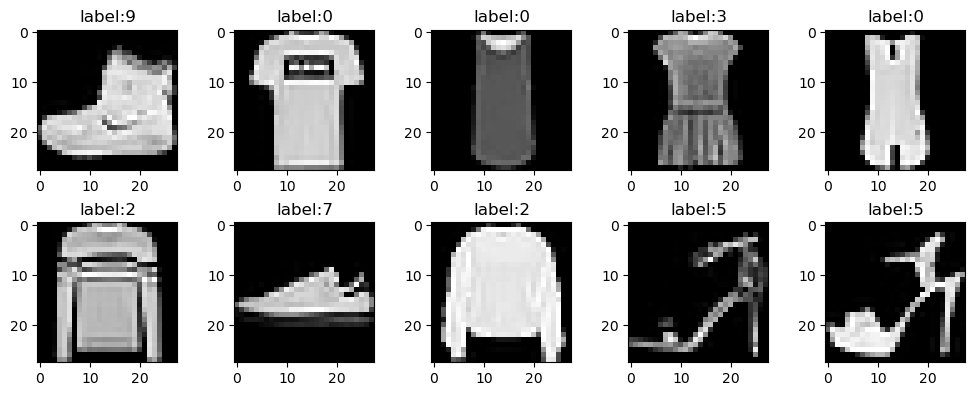

In [130]:
from torchvision.datasets import FashionMNIST

preprocessing = transform.ToTensor()

fashion_mnist = {}

for split in ['train','test']:
    fashion_mnist[split] =FashionMNIST(
        root='data', train=(split=='train'), download=True, transform=preprocessing)
    print(f'{split:<5}: {len(fashion_mnist[split]):,}')


display(pd.DataFrame({'label':FashionMNIST.classes}).T)
plt.figure(figsize=(10,4))

for i, (sample, label) in zip(range(10),fashion_mnist['train']):

    sample = sample.squeeze()
    print(type(sample), sample.shape, sample.dtype)
    plt.subplot(2,5,i+1)
    plt.imshow(sample, cmap='gray')
    plt.title(f'label:{label}')


plt.tight_layout()
plt.show()


In [132]:


model = keras.Sequential([
    keras.Input(shape=(1,28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(10)
])
model.summary()

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = keras.optimizers.RMSprop(learning_rate=1e-3),
    metrics=['accuracy'],
)

%run load_mnist-me.py
data_loader = {}

for split in fashion_mnist.keys():
    data_loader[split] = DataLoader(
        fashion_mnist[split], batch_size=128, shuffle=(split=='train'))



histroy = model.fit(data_loader['train'], epochs=5)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

(split:<5): 60,000
(split:<5): 10,000
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.7450 - loss: 0.7454
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8542 - loss: 0.3982
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8714 - loss: 0.3454
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8816 - loss: 0.3167
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8903 - loss: 0.2941


In [ ]:
# move device

# epoch 증가 
from torch.utils.data import DataLoader

model = nn.Sequential(
    nn.Linear(in_features=28*28, out_features=512),  # keras.Dense( out_feature, 활성)
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=10)
)

print(f'has model fit ? : {hasattr(model, "fit")}') # fit 함수 확인

device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'

loss_func = nn.CrossEntropyLoss()
fitting_func = torch.optim.RMSprop(model.parameters(), lr=1e-3)

# 학습 
data_loader = {}
data_loader['train'] = DataLoader(mnist['train'], batch_size=128, shuffle=True)
loss_history =[]

epoch_cnt = 5

for epoch in range(epoch_cnt):

    for X_batch, y_batch in data_loader['train']:
        # 손실 계산
        outputs = model(X_batch.reshape(-1,784))
        loss =  loss_func(outputs, y_batch)
        loss_history.append(loss.item())

        # 경사 산출 ( 역전파 )
        fitting_func.zero_grad()
        loss.backward()

        # 매게변수 갱신
        fitting_func.step()

    print(f'손실: {epoch+1}/{epoch_cnt} ,  {loss.item():.3f}')




# 매게변수 갱신



